In [37]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

api_key = os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"] = api_key

model = ChatGroq(model="openai/gpt-oss-120b")

In [38]:
from typing import Annotated
from langgraph.graph.message import add_messages


class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [39]:
def chat(state: ChatState):
    messages = state['messages']

    prompt = f'You are an expert assistant answer all the messages {messages}'

    response = model.invoke(prompt)

    return {'messages' : [response]}


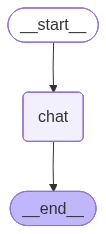

In [40]:
memory = InMemorySaver()

graph = StateGraph(ChatState)

graph.add_node('chat',chat)

graph.add_edge(START,'chat')
graph.add_edge('chat',END)

workflow = graph.compile(checkpointer=memory)

workflow

In [41]:
initial_state = { 'messages' :[ HumanMessage(content='What is the capital of pakistan')]}

workflow.invoke(initial_state)["messages"][-1].content


ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [42]:
thread_id = "1"

print("Welcome to our AI Assistant")

while True:
    user = input("Type here: ")

    if user.lower() in ["exit", "bye", "quit"]:
        break

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    result = workflow.invoke(
        {
            "messages": [HumanMessage(content=user)]
        },
        config=config
    )

    print("AI:", result["messages"][-1].content)

Welcome to our AI Assistant
AI: Hello Kashan! Nice to meet you. How can I assist you today?
AI: Your name is Kashan. How can I help you today?
AI: The capital of India is **New Delhi**. It serves as the seat of the Government of India and houses important institutions such as the President’s House (Rashtrapati Bhavan), Parliament, and the Supreme Court. If you’d like to know more about its history, landmarks, or anything else, just let me know!
AI: The capital of Afghanistan is **Kabul**. It’s the country’s largest city and the political, economic, and cultural hub, situated in a valley surrounded by the Hindu Kush mountains. If you’d like to know more about Kabul’s history, landmarks, or current affairs, just let me know!
AI: Goodbye, Kashan! It was a pleasure chatting with you. If you ever have more questions—whether about world capitals, tech, or anything else—just drop by. Take care!
